# Modern Portfolio Theory and the Efficient Frontier
The premise of the Modern Portfolio Theory is simple: find a portfolio that balances the risk and return to align with an investors risk tolerance. The founder of this theory, economist Harry Markowitz, suggests that the diversification of assets in a portfolio will produce more predictable returns, one of the main ideas of the MPT. This project sets out to engineer a portfolio with the highest risk-adjusted return from a small group of diverse assets.

To begin, we must find a group of diversified assets. A mutually independent set of assets will produce a weak or no correlation. To find the correlation of assets in a portfolio, we plot their correlation matrix. We will use Pearson's method, defined by: $$ \rho_{A,B} = \frac{cov(A, B)}{\sigma_A \sigma_B}$$

$\rho_{A,B}$ = pearson correlation coefficient,

$cov(A, B)$ = $E[(A-\mu_A)(B-\mu_B)]$ = covariance of A and B , and 

$\sigma_A$ and $\sigma_B$ are the standard deviations of A and B respectively.


[*********************100%***********************]  5 of 5 completed


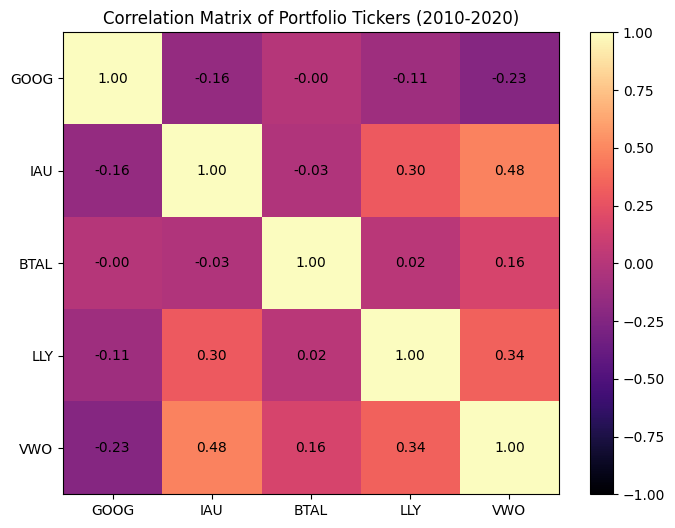

In [1]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# get data
tickers = [ "GOOG", # Tech
            "IAU", # Gold Bullion ETF
            "BTAL", # U.S. Anti-Beta Fund; long low-vol, short high-vol
            "LLY", # Health-care
            "VWO" # Emerging Markets ETF
          ]
df = yf.download(tickers, start="2010-01-01", end="2020-01-01")["Close"]

# arithmetic asset returns
daily_returns = df.pct_change().dropna()
annualized_returns = daily_returns.mean() * 252


# calculate correlation matrix
cor_matrix = daily_returns.corr()

# plot
plt.figure(figsize=(8,6))
plt.imshow(cor_matrix, cmap="magma", aspect="auto", vmin=-1, vmax=1)
plt.colorbar()

for i in range(len(cor_matrix)):
    for j in range(len(cor_matrix)):
        plt.text(i, j, f"{cor_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.xticks(range(len(cor_matrix)), tickers)
plt.yticks(range(len(cor_matrix)), tickers)
plt.title("Correlation Matrix of Portfolio Tickers (2010-2020)")

plt.show()

In statistics, given a correlation $r$, a value of $0 \leq r \leq 0.25$ shows no relationship, and a value of $0.25 < r \leq 0.5$ shows a weak relationship. Since every $r$ in our group shows either a weak or no relationship, we shall conclude that we have found a well diversified portfolio.

Now, let us observe the Efficient Frontier, a tool that is paramount to the Modern Portfolio Theory. Essentially, the Efficient Frontier is the $X$ and $Y$ Graph of the risk and return for thousands of simulated portfolios. We can see that, for a given $x$ value (risk), there are a multitude of inefficient porfolios, ones that do not maximize returns. Under the assumption that investors seek to maximize their returns for a given variance, choosing portfolios that lie on the top frontier are the efficient portfolios, meaning they maximize their return for a given level of risk.

In [ ]:
trials = 10000
asset_returns = daily_returns.values # convert log returns to arithmetic

# initialize variables for best sharpe
best_sharpe = -np.inf
b_sharpe_returns = 0
b_sharpe_risk = 0
best_weights = []

# initialize variables for global minimum variance
min_risk = np.inf
return_min_risk = 0
sharpe_min_risk = 0
min_risk_weights = []

for _ in range(trials):
    
    # create random weights
    nums = np.random.random((5, 1))
    weights = nums / nums.sum()
    
    portfolio_returns = asset_returns @ weights
    annualized_returns = portfolio_returns.mean() * 252

    annualized_risk = portfolio_returns.std() * np.sqrt(252) # risk scales by sqrt(days)

    # sharpe ratio
    risk_free_rate = 0.0385
    sharpe = (annualized_returns - risk_free_rate) / annualized_risk

    # save best sharpe
    if sharpe > best_sharpe:
        best_sharpe = sharpe
        b_sharpe_returns = annualized_returns
        b_sharpe_risk = annualized_risk
        best_weights = weights

    # save min risk
    if annualized_risk < min_risk:
        min_risk = annualized_risk
        return_min_risk = annualized_returns
        sharpe_min_risk = sharpe
        min_risk_weights = weights

    # plot point
    plt.plot(annualized_risk, annualized_returns, "bo", ms=1);

# plot efficient frontier
plt.plot(b_sharpe_risk, b_sharpe_returns, "yo", label="Maximum Risk-Adjusted Returns")
plt.plot(min_risk, return_min_risk, "go", label="Global Minimum Variance")
plt.plot(0, 0.0385, "ro", label="Risk Free Rate (3-Month U.S. T-Bill)")
plt.xlim(left=-0.05)
plt.ylim(top=0.3)

# plot capital market line
cml_sharpe = (b_sharpe_returns - 0.0385) / b_sharpe_risk # to extend line
x = [0, b_sharpe_risk, 1]
y = [0.0385, b_sharpe_returns, cml_sharpe]
plt.plot(x, y, "--", linewidth=1, color="orange", label="Capital Market Line")

plt.title("Efficient Frontier Plot Using Monte Carlo Simulation")
plt.xlabel("Annualized Risk")
plt.ylabel("Annualized Geometric Returns")

plt.legend()
plt.grid(True)

Above, I have singled out two portfolios. The first, in yellow, marks the portfolio with the highest risk-adjusted returns, or Sharpe ratio. The Sharpe ratio is given by: $$ Sharpe = \frac{R_p - r_f}{\sigma_p} $$ 
$R_p$ = Annualized Portfolio Returns, 

$r_f$ = Risk-Free Rate, and 

$\sigma_p$ = Annualized Portfolio Standard Deviation. 

The second, in green, marks the Global Minimum Variance portfolio, or the portfolio with the lowest risk. For the particularly risk-averse of readers, this one may catch your eye.

In addition to these two portfolios, I have plotted the Capital Market Line (CML). Geometrically, it is the line that connects the risk-free rate (in this case the 3-Month U.S. Treasury Bill), to the portfolio with the best Sharpe ratio. It is the line tangent to the Efficient Frontier, passing throught the risk-free rate. Although it may seem insignificant, the CML gives us substantial guidance.

Imagine you are an investor walking this line; where you stand depends especially on your goals. First, to the left of the Max Sharpe Portfolio is where the more risk-averse investor lives. In this region, a mix of lending money at the risk-free rate (buying T-Bills) and buying the Yellow Portfolio will yield maximal returns for a lower risk-profile. Second, the option of standing on the Yellow Portfolio implies 100% capital allocation to it, balancing the risk and reward for a collection of entirely risky assets. Finally, for the more risky investor, the region to the right of the Yellow Portfolio is where the investor should borrow money at the risk-free rate to allocate more than their original capital to the Yellow Portfolio. This will yield the greatest returns, although the risk scales linearly.

Moreover, the slope of the CML gives us the maximum Sharpe ratio. This means that wherever you stand, you are always optimizing your risk-adjsted returns. Where you wish to stand on this line is dictated by your absolute risk tolerance.

In [3]:
print("== Portfolio With the Best Risk-Adjusted Return ==")
print(f"Tickers: {tickers}")
print(f"Weights: {np.round(best_weights.T, 2)}")
print(f"Sharpe Ratio: {best_sharpe:.2f}")
print(f"Average Annual Geometric Returns: {b_sharpe_returns:.2%}")
print(f"Average Annual Risk: {b_sharpe_risk:.2%}")

print()

print("== Portfolio with Global Minimum Variance ==")
print(f"Tickers: {tickers}")
print(f"Weights: {np.round(weights.T, 2)}")
print(f"Sharpe Ratio: {sharpe_min_risk:.2f}")
print(f"Average Annual Geometric Returns: {return_min_risk:.2%}")
print(f"Average Annual Risk: {min_risk:.2%}")

== Portfolio With the Best Risk-Adjusted Return ==
Tickers: ['GOOG', 'IAU', 'BTAL', 'LLY', 'VWO']


NameError: name 'best_weights' is not defined

After finding our portfolio with the best risk-adjusted returns, we now need to implement it. To do so, after gathering portfolio data from the 2010-2020 period, we will now buy and hold our portfolio from 2021-2026, to determine whether this is a profitable strategy.

In [98]:
# backtest
# get data from 2021-2026
data = yf.download(tickers, start="2021-01-01", end="2026-01-01")["Close"]

# get arithmetic returns
bt_returns = data.pct_change().dropna()
port_bt_returns = bt_returns.values @ best_weights
annual_bt_returns = port_bt_returns.mean() * 252

# value of $1 investment
port_value = (1 + port_bt_returns).cumprod()[-1]

# geometric returns (CAGR)
end_value = port_value
start_value = 1
cagr = ( ( (end_value / start_value) ** (1/5) ) - 1)  * 100

# get risk
annual_bt_risk = port_bt_returns.std() * np.sqrt(252)

# get sharpe
port_sharpe = (annual_bt_returns - risk_free_rate) / annual_bt_risk

print("== Portfolio Out-of-Sample Backtest Results ==")
print(f"Compound Annual Growth Rate (Geometric Returns): {cagr:.2f}%")
print(f"Annual Portfolio Risk: {annual_bt_risk:.2%}")
print(f"Portfolio Sharpe Ratio: {port_sharpe:.2f}")
print(f"Value of $1 Initial Investment: ${port_value:.2f}")


[*********************100%***********************]  5 of 5 completed

== Portfolio Out-of-Sample Backtest Results ==
Compound Annual Growth Rate (Geometric Returns): 40.45%
Annual Portfolio Risk: 23.19%
Portfolio Sharpe Ratio: 1.42
Value of $1 Initial Investment: $5.46


As we can see, our portfolio choice was a success! We exceeded the expected return, calculated by its Compound Annual Growth Rate (CAGR), which is a method that accounts for compounding.

$CAGR = ((\frac{EV}{BV}) ^ \frac{1}{years} - 1) * 100$

$\tiny EV$ and $\tiny BV$ are the portfolios ending and beginning values respectively.

We achieved this, though, not without some added risk. Now we can sleep at night knowing our money will grow...

Wait, we must understand one characteristic of the market that we have not yet discussed; the concept of non-stationarity. Non-stationarity refers to the fact that our time-series data is not dictated by a constant mean or standard deviation, but rather ever-changing variables. In essence, the prices are a random walk through time, dictated by so many factors that it is impossible to model accurately. For our portfolio, this means two things. First, it means that our expected returns and risk are not accurate; they are only estimates. Our strategy could spectacularly outperform expectations, or severely fail. Second, it means that the correlation between assets is not constant, and our values only hold true for the 2010-2020 timeframe. The level of diversification of our portfolio, which relies on our correlation matrix, will change over time.

Counterintuitively, it is known that diversification works when you don't need it, and fails when you do. Consistently, during large market drawdowns, the correlation of risky assets explodes to one, and the entire portfolio bleeds in the process. So, before investing in this portfolio, we must understand and be comfortable with the risk of deviations from our expected return, and of potential drawdowns.